# CS 3110/5110: Data Privacy
## In-Class Exercise, 9/15/2025

In [17]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

adult = pd.read_csv('https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv')

## Question 1

Implement the Laplace mechanism below.

In [18]:
def laplace_mech(v, sensitivity, epsilon):
    return v + np.random.laplace(loc=0, scale=sensitivity/epsilon)

In [19]:
# TEST CASE for question 1
dist1 = [laplace_mech(50, 1, 1.0) for _ in range(200)]
dist2 = [np.random.laplace(loc=50, scale=1) for _ in range(200)]

assert stats.wasserstein_distance(dist1, dist2) < 1

## Question 2



In [20]:
def people_over_30_dp():
    sensitivity = 1.0
    epsilon = 1.0
    return np.random.laplace(len(adult[adult['Age'] > 30]), scale=sensitivity/epsilon)

people_over_30_dp()

21991.174708942763

In [21]:
# TEST CASE for question 2
dist1 = [np.random.laplace(loc=21989, scale=1.0) for _ in range(200)]
dist2 = [people_over_30_dp() for _ in range(200)]

assert stats.wasserstein_distance(dist1, dist2) < 1

## Question 3

Consider the following definition of a differencing attack (without differential privacy).

In [22]:
def differencing_attack():
    q1 = adult['Age'].sum()
    q2 = adult[adult['Name'] != 'Karrie Trusslove']['Age'].sum()

    return q1 - q2

print('Differencing attack result:', differencing_attack())

Differencing attack result: 39


Implement a function `dp_differencing_attack` that performs the same attack, but attempts to satisfy differential privacy using the Laplace mechanism. Use the parameters `sensitivity=1` and `epsilon=1.0`.

In [23]:
def dp_differencing_attack():
    q1 = adult['Age'].sum()
    q2 = adult[adult['Name'] != 'Karrie Trusslove']['Age'].sum()
    
    sensitivity = 1
    epsilon = 1.0
    nq1 = np.random.laplace(q1, scale=sensitivity/epsilon)
    nq2 = np.random.laplace(q2, scale=sensitivity/epsilon)

    return nq1-nq2

print('DP Differencing attack result:', dp_differencing_attack())

DP Differencing attack result: 40.007534890202805


In [24]:
# TEST CASE for question 1
dp_results = [dp_differencing_attack() for _ in range(100)]
spec = [np.random.laplace(loc=39, scale=1) for _ in range(100)]
assert stats.wasserstein_distance(dp_results, spec) < 2

## Question 4

What is the *sensitivity* of the `differencing_attack` query defined above, and why?

The sensitivity of the differencing_attack is the maximum allowed age value in the dataset because adding or removing one person changes the result by at most that person’s age

## Question 5

Implement a corrected version of `dp_differencing_attack` that uses the correct sensitivity and thus correctly satisfies differential privacy.

In [25]:
def dp_differencing_attack_corrected():
    q1 = adult['Age'].sum()
    q2 = adult[adult['Name'] != 'Karrie Trusslove']['Age'].sum()
    
    nq1 = np.random.laplace(q1, scale=125/1)
    nq2 = np.random.laplace(q2, scale=125/1)
    return nq1 - nq2

print('DP Differencing attack result:', dp_differencing_attack_corrected())

DP Differencing attack result: 201.18375857826322


#wrong answer

laplace_mech(adult['Age].mean(), sensetivity=0.0036853, epsilon=1.0)

In [26]:
# TEST CASE for question 3
dp_results = [dp_differencing_attack_corrected() for _ in range(100)]
spec = [np.random.laplace(loc=39, scale=125/2.0) for _ in range(100)]
assert stats.wasserstein_distance(dp_results, spec) < 200
assert stats.wasserstein_distance(dp_results, spec) > 50

## Question 6

Write a function `dp_mean_age` that calculates the mean age of members of the dataset.

In [27]:
def mean_age():
    return adult['Age'].mean()

mean_age()

np.float64(38.58164675532078)

In [28]:
def dp_mean_age(epsilon):
    # YOUR CODE HERE

    #split the avarage on two quiries: sum adn count
    #do the division "after" addign noise to achive differential privacy

    #sensetivity is 125 because it is a summation adn max age is 125
    noisy_sum = laplace_mech(adult['Age'].sum(), sensitivity=125, epsilon=epsilon/2)

    #sensetivity is 1 because it is a counting quiry
    noisy_count = laplace_mech(len(adult), sensitivity=1, epsilon=epsilon/2)
    mean = noisy_sum / noisy_count

    #total privacy cost is epsilon/2 + epsilon.2 = epsilon, by sequentil composition
    return mean


In [29]:
# TEST CASE for question 1
results = [dp_mean_age(1) for _ in range(100)]
assert np.abs(np.mean(results) - mean_age()) < 0.1

## Question 7

Write a function `dp_age_sum_clipping` that uses clipping to bound the sensitivity of the sum of ages.

In [30]:
def dp_age_sum_clipping(epsilon, b):
    # YOUR CODE HERE
    #sensetivuty of cliping is b, beacause we enforsed an upper bound of b via clipping
    clipped_sum = adult['Age'].clip(upper=b).sum()

    return np.random.laplace(clipped_sum, scale=b/epsilon)

dp_age_sum_clipping(1.0, 100)

1256160.7697597858

In [31]:
# TEST CASE for question 2
results = [dp_age_sum_clipping(1.0, 100) for _ in range(10)]
assert np.abs(np.mean(results) - adult['Age'].sum()) < 100

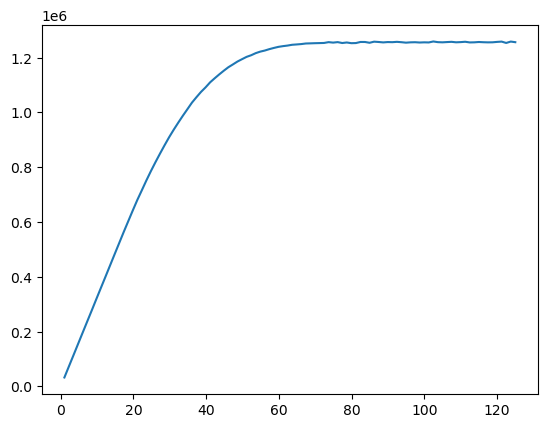

In [32]:
bs = np.linspace(1, 125, 100)
results = [dp_age_sum_clipping(0.1, b) for b in bs]
plt.plot(bs, results);

#baseline = [adult['Age'].sum() for b in bs]
#plt.plot(bs, baseline);